In [11]:
import torch
import json
import os
import hashlib
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import clip
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import yaml
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
import numpy as np
from scipy.optimize import minimize

/home/kritic/miniconda3/envs/dlcv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
class NegationJSONDataset(Dataset):
    """Parses the NegationCLIP annotations JSON"""
    def __init__(self, json_path, max_samples=None, shuffle=True, seed=42):
        with open(json_path, 'r') as f:
            data = json.load(f)
        self.items = data['annotations']
        
        if shuffle:
            import random
            random.seed(seed)
            random.shuffle(self.items)
        
        if max_samples is not None:
            self.items = self.items[:max_samples]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        return {
            "pos_text": item['caption'],
            "neg_text": item['updated_caption'],
            **({"image_id": item['image_id']} if "image_id" in item else {})
        }

In [3]:
class COCOValLlamaDataset(Dataset):
    """Parses the COCO val llama annotations JSON - list of items"""
    def __init__(self, json_path, max_samples=None, shuffle=True, seed=42):
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Handle both dict and list formats
        self.items = data if isinstance(data, list) else list(data.values())
        
        if shuffle:
            import random
            random.seed(seed)
            random.shuffle(self.items)
        
        if max_samples is not None:
            self.items = self.items[:max_samples]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        return {
            "pos_text": item['caption_0'],
            "neg_text": item['caption_1'],
            "image_id": item['image_path']
        }

In [ ]:
# Download COCO images first:
# wget http://images.cocodataset.org/zips/train2014.zip
# unzip train2014.zip

# Then load dataset:
# dataset = NegRefCOCOgDataset(
#     json_path="NegRefCOCOg.json",
#     images_dir="./train2014"
# )

# loader = DataLoader(dataset, batch_size=8)
# batch = next(iter(loader))
# batch['text'] - list of phrases
# batch['crop_ref'] - tensor [B, 3, 224, 224]
# batch['crop_alt'] - tensor [B, 3, 224, 224]

In [55]:
from PIL import Image
import torchvision.transforms as transforms

class NegRefCOCOgDataset(Dataset):
    """Parses the NegRefCOCOg annotations JSON and loads cropped images"""
    def __init__(self, json_path, images_dir="./train2014", max_samples=None, shuffle=True, seed=42):
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # NegRefCOCOg is a list of items
        self.items = data if isinstance(data, list) else list(data.values())
        self.images_dir = images_dir
        
        if shuffle:
            import random
            random.seed(seed)
            random.shuffle(self.items)
        
        if max_samples is not None:
            self.items = self.items[:max_samples]
        
        # Image preprocessing
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.items)
    
    def _crop_bbox(self, image, bbox):
        """Crop image using bounding box [x_min, y_min, x_max, y_max]"""
        if bbox is None or len(bbox) < 4:
            return image
        
        x_min, y_min, width, height = bbox
        x_min, y_min, x_max, y_max = int(x_min), int(y_min), int(x_min + width), int(y_min + height)

        # Ensure bbox is within image bounds
        x_min = max(0, x_min)
        y_min = max(0, y_min)
        x_max = min(image.width, x_max)
        y_max = min(image.height, y_max)
        
        return image.crop((x_min, y_min, x_max, y_max))

    def __getitem__(self, idx):
        item = self.items[idx]
        text = item['phrase']
        image_filename = item['image']
        ref_bbox = item.get('ref_bbox', None)
        bbox_list = item.get('bbox_list', [])
        
        # Load the full image
        image_path = os.path.join(self.images_dir, image_filename)
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            print(f"Warning: Image not found at {image_path}")
            # Return dummy tensors if image not found
            dummy_tensor = torch.zeros(3, 224, 224)
            return {
                "text": text,
                "crop_ref": dummy_tensor,
                "crop_alt": dummy_tensor
            }
        
        # Crop 1: Using ref_bbox (reference bounding box)
        positive_image = self._crop_bbox(image, ref_bbox)
        positive_image_tensor = self.transform(positive_image)

        neg_image_idx = 1 if bbox_list[1] != ref_bbox else 0

        negative_image = self._crop_bbox(image, bbox_list[neg_image_idx])
        negative_image_tensor = self.transform(negative_image)
        
        
        return {
            "text": text,
            "positive_image": positive_image_tensor,
            "negative_image": negative_image_tensor
        }

In [21]:
import random

In [20]:
class VALSEDataset(Dataset):
    """
    Parses VALSE annotations JSON (Visual Semantic Evaluation).
    Format: {id: {"caption": str, "image_file": str, "foil": str}}
    Returns image tensor along with positive and negative texts.
    """
    def __init__(self, json_path, images_dir="./images", max_samples=None, shuffle=True, seed=42):
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Convert dict to list format
        self.items = list(data.values())
        self.images_dir = images_dir
        
        if shuffle:
            random.seed(seed)
            random.shuffle(self.items)
        
        if max_samples is not None:
            self.items = self.items[:max_samples]
        
        # Image preprocessing (same as NegRefCOCOgDataset)
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        
        # Load image
        image_path = os.path.join(self.images_dir, item['image_file'])
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            print(f"Warning: Image not found at {image_path}")
            # Return dummy tensor if image not found
            dummy_tensor = torch.zeros(3, 224, 224)
            return {
                "pos_text": item['caption'],
                "neg_text": item['foil'],
                "image": dummy_tensor
            }
        
        # Apply transforms
        image_tensor = self.transform(image)
        
        return {
            "pos_text": item['caption'],
            "neg_text": item['foil'],
            "image": image_tensor
        }

In [5]:
class FeatureCache:
    def __init__(self, cache_dir="./embeddings_cache"):
        self.cache_dir = cache_dir
        os.makedirs(cache_dir, exist_ok=True)

    def get_cache_path(self, model_variant_name, dataset_name, config):
        """
        model_variant_name: e.g., 'DEO_CLIP_ViT_B32'
        config: dict of hyperparams that affect embeddings (e.g., {'temperature': 0.07})
        """
        config_str = json.dumps(config, sort_keys=True)
        unique_id = hashlib.md5(f"{model_variant_name}_{dataset_name}_{config_str}".encode()).hexdigest()
        return os.path.join(self.cache_dir, f"{model_variant_name}_{unique_id}.pt")

    def save(self, data, path):
        torch.save(data, path)
        print(f"--- Features successfully cached at {path} ---")

    def load(self, path):
        if os.path.exists(path):
            print(f"--- Found cached features: {path} ---")
            return torch.load(path)
        return None

In [6]:
def extract_and_cache(model, dataloader, tokenizer, model_variant_name, config, dataset = "NegationCLIP", device="cuda"):
    """
    Modified to extract from a specific layer specified in config['layer'].
    If 'layer' is -1 or None, it defaults to the final pooled output.
    """
    cache_manager = FeatureCache()
    # Ensure layer is part of the config so the unique cache ID changes per layer
    cache_path = cache_manager.get_cache_path(model_variant_name, dataset, config)
    
    cached_data = cache_manager.load(cache_path)
    if cached_data:
        return cached_data

    pos_text_features, neg_text_features = [], []
    layer_idx = config.get('layer', -1) # Default to final layer

    model.to(device)
    model.eval()
    
    # Helper to get specific layer features
    def get_layer_features(tokens):
        # Access CLIP text encoder: model.token_embedding, model.transformer, model.ln_final
        # We perform the forward pass manually up to the target layer
        x = model.token_embedding(tokens).type(model.dtype)
        x = x + model.positional_embedding.type(model.dtype)
        x = x.permute(1, 0, 2)  # NLD -> LND
        
        # Pass through transformer up to layer_idx
        # If layer_idx is 4, it passes through resblocks[0, 1, 2, 3]
        num_layers = len(model.transformer.resblocks)
        target = layer_idx if layer_idx != -1 else num_layers
        
        for i in range(target):
            x = model.transformer.resblocks[i](x)
            
        x = x.permute(1, 0, 2)  # LND -> NLD
        x = model.ln_final(x).type(model.dtype)

        # Extract [EOS] token representation (the paper suggests this is the strongest signal)
        # tokens.argmax(dim=-1) finds the index of the EOS token for each sentence
        state = x[torch.arange(x.shape[0]), tokens.argmax(dim=-1)]
        return state

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Encoding {model_variant_name} (Layer {layer_idx})"):
            p_tokens = tokenizer(batch['pos_text']).to(device)
            n_tokens = tokenizer(batch['neg_text']).to(device)

            if "DEO" in model_variant_name:
                # Assuming DEO wrapper supports layer-wise extraction
                # p_feat = model.encode_text(batch['pos_text'], layer=layer_idx)
                # n_feat = model.encode_text(batch['neg_text'], layer=layer_idx)
                p_feat = model.encode_text(batch['pos_text'])
                n_feat = model.encode_text(batch['neg_text'])
            else:
                p_feat = get_layer_features(p_tokens)
                n_feat = get_layer_features(n_tokens)

            # Normalize to unit hypersphere
            p_feat = F.normalize(p_feat.float(), p=2, dim=-1)
            n_feat = F.normalize(n_feat.float(), p=2, dim=-1)

            pos_text_features.append(p_feat.cpu())
            neg_text_features.append(n_feat.cpu())

    data_to_cache = {
        "pos_text": torch.cat(pos_text_features),
        "neg_text": torch.cat(neg_text_features),
    }
    
    cache_manager.save(data_to_cache, cache_path)
    return data_to_cache

In [6]:
dataset = COCOValLlamaDataset("COCO_val_mcq_llama3.1_rephrased.json", max_samples=14000)
loader = DataLoader(dataset, batch_size=128, shuffle=False)

In [22]:
import random
import torchvision.transforms as transforms
from PIL import Image
dataset = VALSEDataset("existence.json", max_samples=14000)
loader = DataLoader(dataset, batch_size=128, shuffle=False)

In [ ]:
dataset = NegationJSONDataset("negationclip_captions_train2014.json", max_samples=14000)
loader = DataLoader(dataset, batch_size=128, shuffle=False)

In [57]:
dataset = NegRefCOCOgDataset("NegRefCOCOg.json", max_samples=7000)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

In [121]:
dataset = NegationJSONDataset("gemini_negation_dataset.json", max_samples=14000)
loader = DataLoader(dataset, batch_size=128, shuffle=False)

In [7]:
dataset = NegationJSONDataset("gemini_negation_dataset2.json", max_samples=14000)
loader = DataLoader(dataset, batch_size=128, shuffle=False)

NameError: name 'NegationJSONDataset' is not defined

In [8]:
print(f"Dataset length: {len(dataset)}")
dataset[0]

Dataset length: 10000


{'pos_text': 'A man wearing a suit and striped tie.',
 'neg_text': 'A man wearing a suit and striped tie without any visible signs of distress.'}

In [7]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": -1}
base_model, _ = clip.load("ViT-B/32", device=device)
base_features = extract_and_cache(base_model, loader, clip.tokenize, "Baseline_CLIP_COCOValLlama", base_config, dataset="COCOValLlama", device=device)

--- Found cached features: ./embeddings_cache/Baseline_CLIP_COCOValLlama_dde73a68053404cba0e24193f3a00875.pt ---


/tmp/ipykernel_368465/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


In [111]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": -1}
base_model, _ = clip.load("ViT-B/32", device=device)
base_features = extract_and_cache(base_model, loader, clip.tokenize, "Baseline_CLIP_14000", base_config, device=device)

--- Found cached features: ./embeddings_cache/Baseline_CLIP_14000_d348be7ef9e86f5952b8187a03a6cdac.pt ---


/tmp/ipykernel_273155/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


In [128]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}
base_model, _ = clip.load("ViT-B/32", device=device)
base_features = extract_and_cache(base_model, loader, clip.tokenize, "Baseline_CLIP_Gemini", base_config, dataset="GEMINI_NEGATION", device=device)

Encoding Baseline_CLIP_Gemini (Layer 4): 100%|██████████| 79/79 [00:03<00:00, 26.18it/s]

--- Features successfully cached at ./embeddings_cache/Baseline_CLIP_Gemini_69e9c1072331f9acad27b90f6f251cc6.pt ---


In [7]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}
base_model, _ = clip.load("ViT-B/32", device=device)
base_features = extract_and_cache(base_model, loader, clip.tokenize, "Baseline_CLIP", base_config, dataset="GEMINI_NEGATION_2", device=device)

--- Found cached features: ./embeddings_cache/Baseline_CLIP_c013ac4dc2148e5b54cd9bbd9fe56601.pt ---


/tmp/ipykernel_642353/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


In [16]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}
base_model, _ = clip.load("ViT-B/32", device=device)
base_features = extract_and_cache(base_model, loader, clip.tokenize, "Baseline_CLIP", base_config, dataset="VALSE", device=device)

Encoding Baseline_CLIP (Layer 4): 100%|██████████| 5/5 [00:03<00:00,  1.38it/s]

--- Features successfully cached at ./embeddings_cache/Baseline_CLIP_c4e106130aeda6f0237628bb64bbee03.pt ---


In [14]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}
base_model, _ = clip.load(base_config["arch"], device=device)
checkpoint = torch.load("negationclip_ViT-B32.pth", map_location=device)
base_model.load_state_dict(checkpoint)
base_model.eval()
base_features = extract_and_cache(base_model, loader, clip.tokenize, "NG_CLIP", base_config, dataset="GEMINI_NEGATION_2", device=device)

/tmp/ipykernel_642353/1793343657.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("negationclip_ViT-B32.pth", map_location=device)


--- Found cached features: ./embeddings_cache/NG_CLIP_9cabd262331a3884fc4b914b1606dd58.pt ---


/tmp/ipykernel_642353/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


In [8]:
layers_to_save = range(1, 13) 
for l in layers_to_save:
    current_cfg = {
        "type": "vanilla", 
        "arch": "ViT-B/32", 
        "layer": l
    }
    
    variant_name = "Baseline_CLIP"
    
    print(f"\n>>> Extracting features for Layer {l}...")
    
    extract_and_cache(
        model=base_model, 
        dataloader=loader, 
        dataset = "GEMINI_NEGATION_2",
        tokenizer=clip.tokenize, 
        model_variant_name=variant_name, 
        config=current_cfg,
        device="cuda"
    )

print("\n All 12 layers have been cached successfully.")


>>> Extracting features for Layer 1...
--- Found cached features: ./embeddings_cache/Baseline_CLIP_44a1acc02104c49ca0a7188e099237d6.pt ---

>>> Extracting features for Layer 2...
--- Found cached features: ./embeddings_cache/Baseline_CLIP_4ac52f0cbe026e5e2b8449a57ff774d6.pt ---

>>> Extracting features for Layer 3...
--- Found cached features: ./embeddings_cache/Baseline_CLIP_57f4957efad2cc49374ccc10549c1ffe.pt ---

>>> Extracting features for Layer 4...
--- Found cached features: ./embeddings_cache/Baseline_CLIP_c013ac4dc2148e5b54cd9bbd9fe56601.pt ---

>>> Extracting features for Layer 5...
--- Found cached features: ./embeddings_cache/Baseline_CLIP_dd3dd084a420e337ba8574900f3f9e50.pt ---

>>> Extracting features for Layer 6...
--- Found cached features: ./embeddings_cache/Baseline_CLIP_9a257f1698f842b95b51b64e04ced324.pt ---

>>> Extracting features for Layer 7...
--- Found cached features: ./embeddings_cache/Baseline_CLIP_90ace7aa274531deab3c76091838f26b.pt ---

>>> Extracting feat

/tmp/ipykernel_642353/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


In [ ]:
layers_to_save = range(1, 13) 
for l in layers_to_save:
    current_cfg = {
        "type": "vanilla", 
        "arch": "ViT-B/32", 
        "layer": l
    }
    
    variant_name = "Baseline_CLIP"
    
    print(f"\n>>> Extracting features for Layer {l}...")
    
    extract_and_cache(
        model=base_model, 
        dataloader=loader, 
        dataset = "GEMINI_NEGATION_2",
        tokenizer=clip.tokenize, 
        model_variant_name=variant_name, 
        config=current_cfg,
        device="cuda"
    )

print("\n All 12 layers have been cached successfully.")


>>> Extracting features for Layer 1...


NameError: name 'base_model' is not defined

In [15]:
layers_to_save = range(1, 13) 
for l in layers_to_save:
    current_cfg = {
        "type": "vanilla", 
        "arch": "ViT-B/32", 
        "layer": l
    }
    
    variant_name = "NG_CLIP"
    
    print(f"\n>>> Extracting features for Layer {l}...")
    
    extract_and_cache(
        model=base_model, 
        dataloader=loader, 
        dataset = "GEMINI_NEGATION_2",
        tokenizer=clip.tokenize, 
        model_variant_name=variant_name, 
        config=current_cfg,
        device="cuda"
    )

print("\n All 12 layers have been cached successfully.")


>>> Extracting features for Layer 1...
--- Found cached features: ./embeddings_cache/NG_CLIP_1407c55e24d720c9be34156bc466e531.pt ---

>>> Extracting features for Layer 2...
--- Found cached features: ./embeddings_cache/NG_CLIP_c568c3a63177861c5eaebaaa4bb5b042.pt ---

>>> Extracting features for Layer 3...
--- Found cached features: ./embeddings_cache/NG_CLIP_2e5899d9c8f0d89e8ba93d672d3ab41d.pt ---

>>> Extracting features for Layer 4...
--- Found cached features: ./embeddings_cache/NG_CLIP_9cabd262331a3884fc4b914b1606dd58.pt ---

>>> Extracting features for Layer 5...
--- Found cached features: ./embeddings_cache/NG_CLIP_123793cb41e496902bafe96abfb6fd12.pt ---

>>> Extracting features for Layer 6...
--- Found cached features: ./embeddings_cache/NG_CLIP_f8cf7dd95d94467c8c0b09162b5299f6.pt ---


/tmp/ipykernel_642353/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)



>>> Extracting features for Layer 7...
--- Found cached features: ./embeddings_cache/NG_CLIP_140b60fa19c8b9d43dd407eab00813be.pt ---

>>> Extracting features for Layer 8...
--- Found cached features: ./embeddings_cache/NG_CLIP_b67fbd0ecd850333fd643af0bde7e4f3.pt ---

>>> Extracting features for Layer 9...
--- Found cached features: ./embeddings_cache/NG_CLIP_f49a2374e7906f50cba81250503842c8.pt ---

>>> Extracting features for Layer 10...
--- Found cached features: ./embeddings_cache/NG_CLIP_6d6fc2512470579af6f4b17b95cbfade.pt ---

>>> Extracting features for Layer 11...
--- Found cached features: ./embeddings_cache/NG_CLIP_26e1990f133270f6173b83f85e96a860.pt ---

>>> Extracting features for Layer 12...
--- Found cached features: ./embeddings_cache/NG_CLIP_f7fc1c78586d42998b10849380062c05.pt ---

 All 12 layers have been cached successfully.


In [21]:
layers_to_save = range(1, 13) 
for l in layers_to_save:
    current_cfg = {
        "type": "vanilla", 
        "arch": "ViT-B/32", 
        "layer": l
    }
    
    variant_name = "Baseline_CLIP_COCOValLlama"
    
    print(f"\n>>> Extracting features for Layer {l}...")
    
    extract_and_cache(
        model=base_model, 
        dataloader=loader, 
        dataset = "COCOValLlama",
        tokenizer=clip.tokenize, 
        model_variant_name=variant_name, 
        config=current_cfg,
        device="cuda"
    )

print("\n All 12 layers have been cached successfully.")


>>> Extracting features for Layer 1...


Encoding Baseline_CLIP_COCOValLlama (Layer 1): 100%|██████████| 47/47 [00:01<00:00, 39.07it/s]


--- Features successfully cached at ./embeddings_cache/Baseline_CLIP_COCOValLlama_cdb9f7c5ffea5d1441f91f047b78df6f.pt ---

>>> Extracting features for Layer 2...


Encoding Baseline_CLIP_COCOValLlama (Layer 2): 100%|██████████| 47/47 [00:01<00:00, 37.01it/s]


--- Features successfully cached at ./embeddings_cache/Baseline_CLIP_COCOValLlama_a4354d7505da586a7faa3b8045d2a167.pt ---

>>> Extracting features for Layer 3...


...

--- Features successfully cached at ./embeddings_cache/Baseline_CLIP_COCOValLlama_076eac8f1d367d9a9535bfba98c7fec0.pt ---

>>> Extracting features for Layer 11...


Encoding Baseline_CLIP_COCOValLlama (Layer 11): 100%|██████████| 47/47 [00:02<00:00, 16.34it/s]


--- Features successfully cached at ./embeddings_cache/Baseline_CLIP_COCOValLlama_610a226dfc1e34f8ee839dd508e73de4.pt ---

>>> Extracting features for Layer 12...


Encoding Baseline_CLIP_COCOValLlama (Layer 12): 100%|██████████| 47/47 [00:03<00:00, 15.50it/s]

--- Features successfully cached at ./embeddings_cache/Baseline_CLIP_COCOValLlama_608ac0db4759af14d53b8e8c854ec37c.pt ---

 All 12 layers have been cached successfully.


In [29]:
class SubQueryExtractor:
    def __init__(self, llm_client, model_name, prompt_version="v2", dataset_name="NegationCLIP"):
        self.llm_client = llm_client
        self.llm_model_name = model_name
        self.prompt_version = prompt_version
        self.dataset_name = dataset_name
        
        with open(f"./prompt/{prompt_version}.yaml", 'r') as f:
            self.prompt_config = yaml.safe_load(f)
            
        self.cache_dir = f"./llm_cache/{dataset_name}/{prompt_version}"
        os.makedirs(self.cache_dir, exist_ok=True)

    def _get_cache_path(self, query):
        unique_id = f"{query}_{self.llm_model_name}"
        query_hash = hashlib.md5(unique_id.encode()).hexdigest()
        return os.path.join(self.cache_dir, f"{query_hash}.json")

    def save_to_cache(self, query, parsed_json):
        """Helper to save a single result to the granular cache."""
        cache_path = self._get_cache_path(query)
        result = {
            "query": query,
            "positives": parsed_json.get("positives", []),
            "negatives": parsed_json.get("negatives", []),
            "metadata": {
                "llm_model": self.llm_model_name,
                "prompt_version": self.prompt_version,
                "dataset": self.dataset_name
            }
        }
        with open(cache_path, 'w') as f:
            json.dump(result, f, indent=4)
        return result

    def get_decomposition_batch(self, queries):
        """Processes a list of queries using batch inference."""
        needed_queries = []
        results = {}
        
        for q in queries:
            path = self._get_cache_path(q)
            if os.path.exists(path):
                with open(path, 'r') as f:
                    results[q] = json.load(f)
            else:
                needed_queries.append(q)
        
        # 2. Call LLM for the missing ones in a single batch
        if needed_queries:
            system_msg = self.prompt_config['system']
            # We assume llm_client now has a .generate_batch method
            batch_responses = self.llm_client.generate_batch(system_msg, needed_queries)
            
            for q, resp in zip(needed_queries, batch_responses):
                results[q] = self.save_to_cache(q, resp)
                
        return [results[q] for q in queries]

In [24]:
class LocalQwenClient:
    def __init__(self, model_id, device="cuda"):
        self.device = device
        self.model_id = model_id
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        
        # CRITICAL for batching: Decoder-only models must pad on the left
        self.tokenizer.padding_side = "left"
        
        # Ensure a pad token exists
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
            
        self.model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype="auto",
            device_map=device
        )

    def generate_batch(self, system_prompt, queries):
        """
        Processes a list of queries in a single GPU forward pass.
        """
        formatted_texts = []
        for q in queries:
            messages = [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f'Query: "{q}"'}
            ]
            # apply_chat_template handles the im_start/im_end tokens for Qwen
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
            formatted_texts.append(text)


        inputs = self.tokenizer(
            formatted_texts, 
            return_tensors="pt", 
            padding=True
        ).to(self.device)

        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs,
                max_new_tokens=512,
                temperature=0.1,
                do_sample=False,
                pad_token_id=self.tokenizer.pad_token_id
            )

        responses = []
        input_len = inputs.input_ids.shape[1]
        batch_output_ids = generated_ids[:, input_len:]
        decoded_outputs = self.tokenizer.batch_decode(batch_output_ids, skip_special_tokens=True)

        for i, response in enumerate(decoded_outputs):
            try:
                match = re.search(r'\{.*\}', response, re.DOTALL)
                if match:
                    clean_json = match.group(0)
                    responses.append(json.loads(clean_json))
                else:
                    raise ValueError("No JSON block found")
                    
            except (json.JSONDecodeError, ValueError) as e:
                print(f"Extraction Error for: {queries[i][:30]}... trying simple fallback.")
                responses.append({
                    "positives": [queries[i]], 
                    "negatives": []
                })
        
        return responses

    def __call__(self, system_prompt, user_prompt):
        """Maintains backward compatibility for single calls."""
        return self.generate_batch(system_prompt, [user_prompt])[0]

qwen_client = LocalQwenClient(model_id="Qwen/Qwen2.5-1.5B-Instruct")

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 299.35it/s]


In [23]:
# Update your extractor to use this new client
extractor = SubQueryExtractor(
    llm_client=qwen_client, 
    model_name=qwen_client.model_id, 
    prompt_version="v2",
    dataset_name="COCOValLlama"
)

In [30]:
#"Qwen/Qwen3-4B-Instruct-2507"
qwen_client = LocalQwenClient(model_id="Qwen/Qwen3-4B-Instruct-2507")
extractor = SubQueryExtractor(
    llm_client=qwen_client, 
    model_name=qwen_client.model_id, 
    prompt_version="v1",
    dataset_name="VALSE"
)

Fetching 3 files:   0%|          | 0/3 [01:00<?, ?it/s]


RuntimeError: Data processing error: File reconstruction error: IO Error: No space left on device (os error 28)

In [25]:
# Update your extractor to use this new client
extractor = SubQueryExtractor(
    llm_client=qwen_client, 
    model_name=qwen_client.model_id, 
    prompt_version="v2",
    dataset_name="VALSE"
)

In [26]:
def extract_all_decompositions(dataloader, batch_size=16):
    """
    Parallelized extraction for both Positive and Negative captions.
    Optimized for GPU batching with Qwen.
    FIX: Cache ALL items in each batch, not just [0]
    """
    print(f"Starting batched decomposition for {len(dataloader)} samples (Pos + Neg paths)...")
    
    # 1. Collect all unique queries from the dataset
    all_queries = []

    if "pos_text" in dataloader.dataset[0] and "neg_text" in dataloader.dataset[0]:
        for batch in tqdm(dataloader, desc="Scanning Dataset"):
            # FIXED: Extract ALL items in the batch, not just [0]
            all_queries.extend(batch['pos_text'])  # batch['pos_text'] is already a list
            all_queries.extend(batch['neg_text'])  # batch['neg_text'] is already a list
    else:
        all_queries = [item['text'] for item in dataloader.dataset]
    
    # 2. Filter for only those NOT in cache to save GPU time
    # Use a set to handle cases where different images share the same caption
    unique_queries = list(set(all_queries))
    queries_to_process = [q for q in unique_queries if not os.path.exists(extractor._get_cache_path(q))]
    
    cached_count = len(unique_queries) - len(queries_to_process)
    print(f"Total Unique: {len(unique_queries)} | Cached: {cached_count} | To Process: {len(queries_to_process)}")

    if not queries_to_process:
        print("All queries already cached. Skipping LLM phase.")
        return

    # 3. Process missing queries in Batches
    stats = {"new_api_calls": 0, "errors": 0}
    
    for i in tqdm(range(0, len(queries_to_process), batch_size), desc="GPU Batch Inference"):
        chunk = queries_to_process[i : i + batch_size]
        
        try:
            # This calls the LocalQwenClient.generate_batch method
            # Which is managed inside the SubQueryExtractor.get_decomposition_batch
            extractor.get_decomposition_batch(chunk)
            stats["new_api_calls"] += len(chunk)
            
        except Exception as e:
            print(f"\nBatch Error at index {i}: {e}")
            stats["errors"] += len(chunk)

    print("\n--- Extraction Summary ---")
    print(f"Total Unique Queries: {len(unique_queries)}")
    print(f"Loaded from Cache:    {cached_count}")
    print(f"Newly Extracted:      {stats['new_api_calls']}")
    print(f"Failed:               {stats['errors']}")
    print(f"Cache location:       {extractor.cache_dir}")

In [27]:
extract_all_decompositions(loader, batch_size=8)

Starting batched decomposition for 5 samples (Pos + Neg paths)...


Scanning Dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Scanning Dataset: 100%|██████████| 5/5 [00:02<00:00,  1.80it/s]


Total Unique: 641 | Cached: 334 | To Process: 307


GPU Batch Inference:   3%|▎         | 1/39 [00:12<08:06, 12.80s/it]

...

Extraction Error for: There are no zebras facing rig... trying simple fallback.
Extraction Error for: There are no people on the clo... trying simple fallback.


GPU Batch Inference:  92%|█████████▏| 36/39 [04:19<00:27,  9.12s/it]

Extraction Error for: There is no person pictured.... trying simple fallback.


GPU Batch Inference: 100%|██████████| 39/39 [04:26<00:00,  6.82s/it]


--- Extraction Summary ---
Total Unique Queries: 641
Loaded from Cache:    334
Newly Extracted:      307
Failed:               0
Cache location:       ./llm_cache/VALSE/v2


In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
from clip.simple_tokenizer import SimpleTokenizer

class DEOModel(nn.Module):
    def __init__(self, clip_model, extractor, config, device="cuda"):
        super().__init__()
        self.base_model = clip_model
        self.extractor = extractor
        self.device = device
        self.tokenizer = SimpleTokenizer()
        
        self.lr = config.get('lr', 0.001)
        self.steps = config.get('steps', 50)
        self.pos_weight = config.get('pos_weight', 0.4)
        self.neg_weight = config.get('neg_weight', 0.4)
        self.reg_weight = config.get('reg_weight', 1.0)
        
        self.logit_scale = clip_model.logit_scale
        self.visual = clip_model.visual

    def _get_emb(self, texts):
        if not texts or len(texts) == 0:
            return None
        tokens = clip.tokenize(texts).to(self.device)
        with torch.no_grad():
            return F.normalize(self.base_model.encode_text(tokens).float(), p=2, dim=-1)

    def encode_text(self, raw_text=None):
        """
        Processes text using DEO optimization if raw_text is valid.
        If tokens represent padding/empty, it returns vanilla embeddings.
        """
        # Ensure raw_text is a list for batch consistency
        if isinstance(raw_text, str):
            raw_text = [raw_text]

        # 2. LLM Decomposition (Uses exact strings for cache hits)
        batch_meta = self.extractor.get_decomposition_batch(raw_text)
        
        # 3. Anchor Preparation
        with torch.no_grad():
            # Original CLIP embeddings for the raw queries
            orig_embs = self._get_emb(raw_text) 
            pos_anchors = [self._get_emb(m.get('positives', [])) for m in batch_meta]
            neg_anchors = [self._get_emb(m.get('negatives', [])) for m in batch_meta]

        # 4. Optimization Setup
        # Create leaf parameter for gradients
        updated_embs = orig_embs.clone().detach().requires_grad_(True)
        optimizer = torch.optim.Adam([updated_embs], lr=self.lr)

        # 5. Iterative Geometric Optimization Loop
        with torch.enable_grad():
            for _ in range(self.steps):
                optimizer.zero_grad()
                
                batch_loss = 0
                for i in range(len(raw_text)):
                    # Regularization: Stay close to the original semantics
                    dev_loss = torch.norm(updated_embs[i] - orig_embs[i])
                    
                    # Positive Pull: Attract to expanded positive intents
                    p_loss = 0
                    if pos_anchors[i] is not None:
                        p_loss = torch.norm(updated_embs[i] - pos_anchors[i], dim=1).mean()
                    
                    # Negative Push: Repel from explicitly negated intents
                    n_loss = 0
                    if neg_anchors[i] is not None:
                        n_loss = torch.norm(updated_embs[i] - neg_anchors[i], dim=1).mean()

                    batch_loss += (self.reg_weight * dev_loss + 
                                   self.pos_weight * p_loss - 
                                   self.neg_weight * n_loss)

                # BACKWARD: Call once after accumulating the full batch loss
                (batch_loss / len(raw_text)).backward()
                optimizer.step()

                # CONSTRAINT: Project back onto the CLIP unit hypersphere
                with torch.no_grad():
                    updated_embs.data = F.normalize(updated_embs.data, p=2, dim=-1)

        return updated_embs.detach()

    def encode_image(self, image):
        return self.base_model.encode_image(image)

    def forward(self, image, text_tokens, raw_text=None):
        image_features = F.normalize(self.encode_image(image), p=2, dim=-1)
        text_features = F.normalize(self.encode_text(text_tokens, raw_text=raw_text), p=2, dim=-1)
        
        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()

        return logits_per_image, logits_per_text

In [16]:
deo_baseline_model = DEOModel(base_model, extractor, config={
    "lr": 0.01,
    "steps": 20,
    "pos_weight": 1.0,
    "neg_weight": 1.0,
    "reg_weight": 0.2
})
deo_base_config = {"type": "vanilla", "arch": "ViT-B/32"}
deo_base_features = extract_and_cache(deo_baseline_model, loader, clip.tokenize, "DEO_CLIP", deo_base_config, device=device)

Encoding DEO_CLIP (Layer -1): 100%|██████████| 47/47 [03:59<00:00,  5.09s/it]

--- Features successfully cached at ./embeddings_cache/DEO_CLIP_6673ee85278670e3ea4346a14ee96680.pt ---


In [12]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import  os
import json

def train_binary_negation_classifier(z_pos, z_neg, config):
    device = config.get('device', 'cuda')
    epochs = config.get('epochs', 150)
    lr = config.get('lr', 1e-3)
    batch_size = config.get('batch_size', 64)
    val_split = config.get('val_split', 0.2)
    
    # 1. Prepare Data
    z_pos = z_pos.float().cpu() 
    z_neg = z_neg.float().cpu()

    num_pairs = len(z_pos)

    # FIX: Split by pairs to prevent data leakage!
    indices = torch.randperm(num_pairs)
    val_size = int(num_pairs * val_split)
    
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    
    # Slice the paired data
    train_z_pos, train_z_neg = z_pos[train_indices], z_neg[train_indices]
    val_z_pos, val_z_neg = z_pos[val_indices], z_neg[val_indices]
    
    # Now concatenate positive and negative samples for train and val respectively
    X_train = torch.cat([train_z_pos, train_z_neg], dim=0)
    y_train = torch.cat([torch.zeros(len(train_z_pos)), torch.ones(len(train_z_neg))], dim=0)
    
    X_val = torch.cat([val_z_pos, val_z_neg], dim=0)
    y_val = torch.cat([torch.zeros(len(val_z_pos)), torch.ones(len(val_z_neg))], dim=0)
    
    # Shuffle the resulting datasets so 0s and 1s aren't clumped
    train_ds = TensorDataset(X_train, y_train)
    val_ds = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    
    # 2. Model Setup
    # Use X_train to get the feature dimension
    classifier = nn.Linear(X_train.shape[1], 1).to(device).float()
    nn.init.normal_(classifier.weight, mean=0, std=0.01)
    nn.init.zeros_(classifier.bias)

    # Using Adam Optimizer
    optimizer = optim.Adam(classifier.parameters(), lr=lr, weight_decay=1e-5)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'lrs': []
    }

    best_val_acc = 0.0
    best_w = None

    for epoch in range(epochs):
        # --- Training ---
        classifier.train()
        train_loss, train_correct = 0, 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = classifier(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            
            if torch.isnan(loss):
                print(f"NaN detected at epoch {epoch+1}. Stopping.")
                return None, history
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            train_correct += (preds == batch_y).sum().item()
            
        # --- Validation ---
        classifier.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for v_batch_X, v_batch_y in val_loader:
                v_batch_X, v_batch_y = v_batch_X.to(device), v_batch_y.to(device)
                v_outputs = classifier(v_batch_X).squeeze()
                v_loss = criterion(v_outputs, v_batch_y)
                val_loss += v_loss.item()
                v_preds = (torch.sigmoid(v_outputs) > 0.5).float()
                val_correct += (v_preds == v_batch_y).sum().item()

        current_val_acc = val_correct / len(X_val)
        avg_val_loss = val_loss / len(val_loader)
        
        scheduler.step(avg_val_loss)

        # Save weights from the best-performing epoch
        if current_val_acc > best_val_acc:
            best_val_acc = current_val_acc
            best_w = classifier.weight.data.detach().clone()

        # Record History
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_correct / len(X_train))
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(current_val_acc)
        history['lrs'].append(optimizer.param_groups[0]['lr'])

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d} | Train Acc: {history['train_acc'][-1]:.4f} | Loss: {history['train_loss'][-1]:.5f} | Val Acc: {current_val_acc:.4f} | Loss: {history['val_loss'][-1]:.5f} | LR: {history['lrs'][-1]:.1e}")

    # Return Best Direction Vector
    if best_w is None:
        return None, history
        
    W_dir = F.normalize(best_w.float(), p=2, dim=-1)
    return W_dir, history

In [13]:
def steer_embeddings(h_l, W_dir, alpha):
    """
    h_l: Original hidden states [N, D]
    W_dir: Normalized classifier weights [1, D]
    alpha: Steering hyperparameter
    """
    norm_h = torch.norm(h_l, p=2, dim=-1, keepdim=True) # ||h_l||
    # Steering formula
    h_steered = (1 - alpha) * h_l + alpha * W_dir * norm_h
    return h_steered

In [14]:
def run_paper_negation_experiment(config):
    torch.manual_seed(config['seed'])
    cache_manager = FeatureCache()
    device = config['device']
    
    # 1. Load Data
    pos_path = cache_manager.get_cache_path(config['pos_variant'], config['dataset'], config['pos_config'])
    neg_path = cache_manager.get_cache_path(config['neg_variant'], config['dataset'], config['neg_config'])
    pos_data, neg_data = cache_manager.load(pos_path), cache_manager.load(neg_path)
    
    z_pos, z_neg = pos_data['pos_text'], neg_data['neg_text']

    # 2. Train/Test Split (Classifier only sees Train part)
    indices = torch.randperm(z_pos.size(0))
    train_size = int(config['split_ratio'] * z_pos.size(0))
    train_idx, test_idx = indices[:train_size], indices[train_size:]
    
    # 3. Learn Direction (Returns Training & Validation history)
    W_dir, history = train_binary_negation_classifier(
        z_pos[train_idx], z_neg[train_idx], config
    )

    # 4. Final Evaluation (On the absolute Test Set)
    with torch.no_grad():
        test_p = z_pos[test_idx].to(device).float()
        test_n = z_neg[test_idx].to(device).float()
        
        # A. Calculate Test Accuracy of the Classifier
        # This confirms if negation is linearly separable on unseen data
        test_X = torch.cat([test_p, test_n], dim=0)
        test_y = torch.cat([torch.zeros(len(test_p)), torch.ones(len(test_n))], dim=0).to(device)
        
        # Reconstruct classifier logic for a single pass
        test_logits = (test_X @ W_dir.T).squeeze() # Bias omitted as W_dir is the normalized direction
        test_preds = (test_logits > 0).float() # Using 0 as threshold for normalized direction
        test_acc = (test_preds == test_y).sum().item() / len(test_y)

        # B. Steering Evaluation (Equation 1)
        steered_p = steer_embeddings(test_p, W_dir, config['alpha'])
        
        # Final Similarities
        p_n, n_n, s_p_n = F.normalize(test_p, p=2), F.normalize(test_n, p=2), F.normalize(steered_p, p=2)
        baseline_sim = torch.cosine_similarity(p_n, n_n).mean().item()
        final_sim = torch.cosine_similarity(s_p_n, n_n).mean().item()

    # 5. Reporting
    print(f"\n" + "="*30)
    print(f"NEGATION EXPERIMENT: {config['pos_variant']}")
    print(f"="*30)
    print(f"Classifier Training Acc:   {history['train_acc'][-1]:.2%}")
    print(f"Classifier Validation Acc: {history['val_acc'][-1]:.2%}")
    print(f"Classifier Test Acc:       {test_acc:.2%}")
    print(f"-"*30)
    print(f"Baseline Cosine Sim:       {baseline_sim:.4f}")
    print(f"Steered Cosine Sim:        {final_sim:.4f}")
    print(f"Total Gain:                {final_sim - baseline_sim:.4f}")
    print(f"="*30)

    output = {
        "W_dir": W_dir.cpu(),
        "history": history,
        "test_acc": test_acc,
        "baseline_sim": baseline_sim,
        "result_sim": final_sim,
        "gain": final_sim - baseline_sim
    }

    results_dir = "learned_vectors"
    os.makedirs(results_dir, exist_ok=True) 
    
    config_dict = {
        "dataset": config['dataset'],
        "pos_variant": config['pos_variant'],
        "neg_variant": config['neg_variant'],
        "pos_config": config['pos_config'],
        "neg_config": config['neg_config'],
    }

    # 🔹 Step 2: convert to stable string
    config_str = json.dumps(config_dict, sort_keys=True)

    # 🔹 Step 3: hash it
    hash_id = hashlib.sha1(config_str.encode()).hexdigest()[:8]

    # 🔹 Optional: readable prefix (safe)
    safe_name = f"{config['dataset']}_{config['pos_variant']}_{config['neg_variant']}".replace("/", "-")

    # 🔹 Final filename
    save_filename = f"{safe_name}_{hash_id}_negation_vector.pt"
    save_path = os.path.join(results_dir, save_filename)

    # 🔹 Save tensor
    torch.save(output, save_path)

    # 🔹 Save config for reproducibility
    with open(os.path.join(results_dir, f"{safe_name}_{hash_id}_config.json"), "w") as f:
        f.write(config_str)

    print(f"Learned vector and metrics saved to: {save_path}")

    return output

In [16]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}

# If you want to compare against your DEO features, use that config
# Otherwise, you can compare Baseline Pos vs Baseline Neg
exp_config = {
    'dataset': "GEMINI_NEGATION_2",       
    'pos_variant': 'NG_CLIP',    # Must match the name used in extract_and_cache
    'neg_variant': 'NG_CLIP',    # Can be DEO_CLIP if you cached that,,
    'pos_config': base_config,
    'neg_config': base_config,
    'split_ratio': 0.8,                # Train/Test split for the classifier
    'val_split': 0.2,                  # Internal validation for the classifier
    'alpha': 0.5,                      # Steering strength (from the paper)
    'lr': 0.01,                        # Classifier learning rate
    'epochs': 40,                      # Classifier training epochs
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42
}
run_paper_negation_experiment(exp_config)

--- Found cached features: ./embeddings_cache/NG_CLIP_9cabd262331a3884fc4b914b1606dd58.pt ---
--- Found cached features: ./embeddings_cache/NG_CLIP_9cabd262331a3884fc4b914b1606dd58.pt ---


/tmp/ipykernel_714042/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Epoch 001 | Train Acc: 0.9263 | Loss: 0.38728 | Val Acc: 0.9678 | Loss: 0.23266 | LR: 1.0e-02
Epoch 010 | Train Acc: 0.9901 | Loss: 0.05138 | Val Acc: 0.9922 | Loss: 0.04837 | LR: 1.0e-02
Epoch 020 | Train Acc: 0.9930 | Loss: 0.03758 | Val Acc: 0.9934 | Loss: 0.03545 | LR: 1.0e-02
Epoch 030 | Train Acc: 0.9935 | Loss: 0.03570 | Val Acc: 0.9928 | Loss: 0.03406 | LR: 1.0e-02
Epoch 040 | Train Acc: 0.9934 | Loss: 0.03496 | Val Acc: 0.9941 | Loss: 0.03311 | LR: 1.0e-02

NEGATION EXPERIMENT: NG_CLIP
Classifier Training Acc:   99.34%
Classifier Validation Acc: 99.41%
Classifier Test Acc:       97.67%
------------------------------
Baseline Cosine Sim:       0.9553
Steered Cosine Sim:        0.7490
Total Gain:                -0.2063
Learned vector and metrics saved to: learned_vectors/GEMINI_NEGATION_2_NG_CLIP_NG_CLIP_06a2836d_negation_vector.pt


{'W_dir': tensor([[-2.5489e-02,  1.1265e-01, -4.8359e-02, -4.8902e-02,  1.3166e-02,
          -2.3928e-02, -2.6880e-02,  3.3323e-02,  3.6212e-02,  8.5847e-02,
           4.7395e-02, -7.2451e-03,  5.3895e-02, -4.2728e-02,  5.2685e-02,
           1.0339e-01, -1.9472e-03, -3.6235e-02,  2.0662e-02,  1.7903e-02,
           2.1199e-02,  1.7991e-02, -6.2289e-03, -3.7360e-02, -1.0649e-01,
           3.6563e-03, -5.4937e-02,  9.5337e-03,  1.0549e-02, -3.8720e-02,
          -3.8574e-02, -7.6844e-02, -5.8511e-03,  3.3554e-03, -2.9305e-02,
           3.1520e-03,  4.9112e-02, -4.3389e-03,  6.0065e-02,  5.3916e-03,
          -5.8481e-02, -2.5099e-03,  1.9697e-02,  4.6634e-03, -5.0734e-02,
           4.5879e-02,  4.7600e-03,  3.1336e-02, -1.9579e-02, -2.8431e-02,
           3.3182e-02, -2.8410e-02, -2.7578e-02,  3.0317e-03, -4.6043e-02,
          -3.7925e-02, -5.1103e-02,  1.5846e-02, -6.1208e-02,  3.5100e-02,
           3.9092e-03,  8.0599e-02,  2.8731e-02, -8.0385e-02,  4.5223e-02,
          -5.664


ITERATING OVER LAYERS 1-12 TO FIND OPTIMAL LAYER

[1/12] Running experiment with Layer 1...
--- Found cached features: ./embeddings_cache/NG_CLIP_1407c55e24d720c9be34156bc466e531.pt ---
--- Found cached features: ./embeddings_cache/NG_CLIP_1407c55e24d720c9be34156bc466e531.pt ---


/tmp/ipykernel_714042/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Epoch 001 | Train Acc: 0.9200 | Loss: 0.40083 | Val Acc: 0.9509 | Loss: 0.26620 | LR: 1.0e-02
Epoch 010 | Train Acc: 0.9611 | Loss: 0.13056 | Val Acc: 0.9609 | Loss: 0.13045 | LR: 1.0e-02
Epoch 020 | Train Acc: 0.9660 | Loss: 0.11133 | Val Acc: 0.9653 | Loss: 0.10996 | LR: 1.0e-02
Epoch 030 | Train Acc: 0.9680 | Loss: 0.10515 | Val Acc: 0.9656 | Loss: 0.10513 | LR: 1.0e-02
Epoch 040 | Train Acc: 0.9686 | Loss: 0.10258 | Val Acc: 0.9672 | Loss: 0.10219 | LR: 1.0e-02
Epoch 050 | Train Acc: 0.9681 | Loss: 0.10173 | Val Acc: 0.9669 | Loss: 0.10134 | LR: 1.0e-02
Epoch 060 | Train Acc: 0.9687 | Loss: 0.10111 | Val Acc: 0.9691 | Loss: 0.10050 | LR: 1.0e-02
Epoch 070 | Train Acc: 0.9687 | Loss: 0.10054 | Val Acc: 0.9700 | Loss: 0.10067 | LR: 1.0e-02
Epoch 080 | Train Acc: 0.9680 | Loss: 0.10039 | Val Acc: 0.9678 | Loss: 0.09999 | LR: 1.0e-02
Epoch 090 | Train Acc: 0.9688 | Loss: 0.10031 | Val Acc: 0.9700 | Loss: 0.10017 | LR: 1.0e-02
Epoch 100 | Train Acc: 0.9685 | Loss: 0.10013 | Val Acc: 0.9

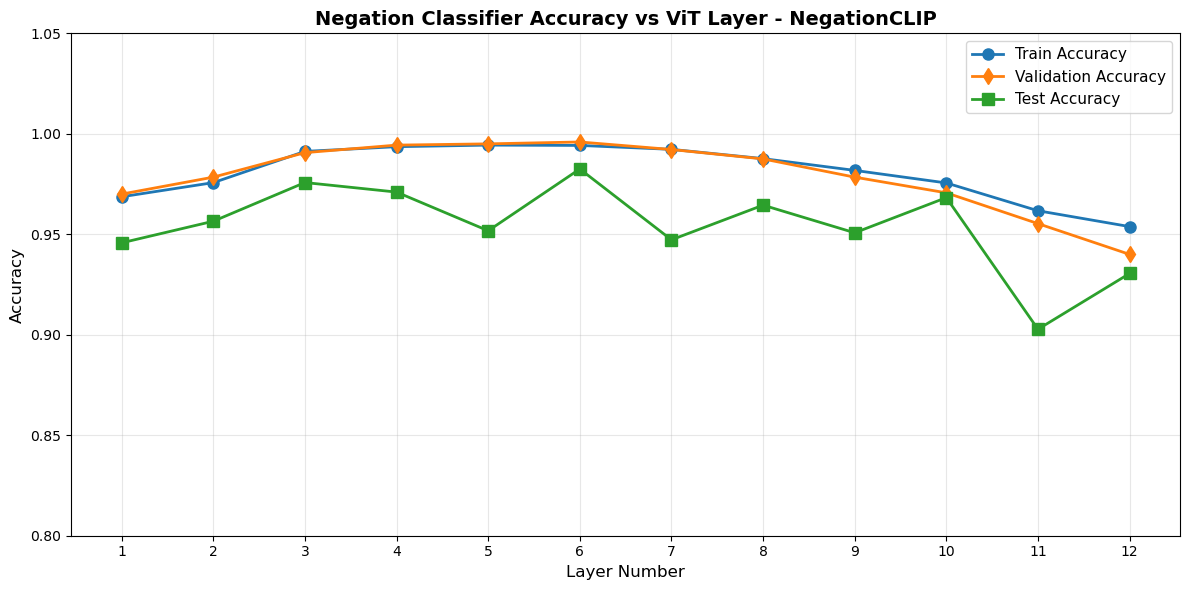


LAYER-BY-LAYER RESULTS:
----------------------------------------------------------------------
Layer    Train Acc       Validation Acc  Test Acc        Difference     
----------------------------------------------------------------------
1        0.9687          0.9700          0.9457          0.0229         
2        0.9757          0.9784          0.9565          0.0192         
3        0.9912          0.9906          0.9758          0.0155         
4        0.9936          0.9944          0.9710          0.0226         
5        0.9944          0.9950          0.9517          0.0426          ← Best Train
6        0.9942          0.9959          0.9825          0.0117          ← Best Test ← Best Validation
7        0.9923          0.9922          0.9473          0.0450         
8        0.9877          0.9875          0.9645          0.0232         
9        0.9818          0.9784          0.9507          0.0310         
10       0.9755          0.9706          0.9683          0.0

In [17]:
import matplotlib.pyplot as plt

# Configuration template - will iterate over layers
base_config_template = {"type": "vanilla", "arch": "ViT-B/32", "layer": None}

# Common experiment config
exp_config_template = {
    'dataset': "GEMINI_NEGATION_2",       
    'pos_variant': 'NG_CLIP',    # Must match the name used in extract_and_cache
    'neg_variant': 'NG_CLIP',    # Can be DEO_CLIP if you cached that
    'split_ratio': 0.8,                # Train/Test split for the classifier
    'val_split': 0.2,                  # Internal validation for the classifier
    'alpha': 0.5,                      # Steering strength (from the paper)
    'lr': 0.01,                        # Classifier learning rate
    'epochs': 120,                      # Classifier training epochs
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42
}

# Store results for each layer
layers = list(range(1, 13))  # Layers 1 to 12
train_accuracies = []
test_accuracies = []
val_accuracies = []
layer_results = {}

print("\n" + "="*70)
print("ITERATING OVER LAYERS 1-12 TO FIND OPTIMAL LAYER")
print("="*70)

# Iterate over each layer
for layer_idx, layer in enumerate(layers, 1):
    print(f"\n[{layer_idx}/12] Running experiment with Layer {layer}...")
    
    # Update config for this layer
    base_config = base_config_template.copy()
    base_config['layer'] = layer
    
    exp_config = exp_config_template.copy()
    exp_config['pos_config'] = base_config
    exp_config['neg_config'] = base_config
    
    # Run experiment
    try:
        results = run_paper_negation_experiment(exp_config)
        
        # Extract train and test accuracy from results
        # Assuming results dict contains 'train_accuracy' and 'test_accuracy'
        if isinstance(results, dict):
            train_acc = results.get('history', 0.0)
            if train_acc != 0.0:
                train_acc = train_acc['train_acc'][-1]  # Extract final training accuracy

            val_acc = results.get('history', 0.0)
            if val_acc != 0.0:
                val_acc = val_acc['val_acc'][-1]  # Extract final validation accuracy
            test_acc = results.get('test_acc', 0.0)

        else:
            # If results is a tuple/list, assume (train_acc, test_acc)
            train_acc = results[0] if len(results) > 0 else 0.0
            test_acc = results[1] if len(results) > 1 else 0.0
        
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        test_accuracies.append(test_acc)
        layer_results[layer] = {'train': train_acc, 'test': test_acc, 'val': val_acc}
        
        print(f"  ✓ Layer {layer}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")
    except Exception as e:
        print(f"  ✗ Error with Layer {layer}: {e}")
        train_accuracies.append(0.0)
        val_accuracies.append(0.0)
        test_accuracies.append(0.0)
        layer_results[layer] = {'train': 0.0, 'test': 0.0, 'val': 0.0}

# Plot results
print("\n" + "="*70)
print("PLOTTING RESULTS")
print("="*70)

plt.figure(figsize=(12, 6))
plt.plot(layers, train_accuracies, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(layers, val_accuracies, 'd-', label='Validation Accuracy', linewidth=2, markersize=8)
plt.plot(layers, test_accuracies, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Layer Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Negation Classifier Accuracy vs ViT Layer - NegationCLIP', fontsize=14, fontweight='bold')
plt.xticks(layers)
plt.ylim([0.8, 1.05])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary
print("\nLAYER-BY-LAYER RESULTS:")
print("-" * 70)
print(f"{'Layer':<8} {'Train Acc':<15} {'Validation Acc':<15} {'Test Acc':<15} {'Difference':<15}")
print("-" * 70)

best_layer_train = max(layer_results.items(), key=lambda x: x[1]['train'])
best_layer_test = max(layer_results.items(), key=lambda x: x[1]['test'])
best_layer_val = max(layer_results.items(), key=lambda x: x[1]['val'])

for layer in layers:
    train_acc = layer_results[layer]['train']
    val_acc = layer_results[layer]['val']
    test_acc = layer_results[layer]['test']
    diff = abs(train_acc - test_acc)
    marker = ""
    if layer == best_layer_train[0]:
        marker += " ← Best Train"
    if layer == best_layer_test[0]:
        marker += " ← Best Test"
    if layer == best_layer_val[0]:
        marker += " ← Best Validation"
    print(f"{layer:<8} {train_acc:<15.4f} {val_acc:<15.4f} {test_acc:<15.4f} {diff:<15.4f}{marker}")

print("-" * 70)
print(f"\n✓ Best Layer (Train):  Layer {best_layer_train[0]} with {best_layer_train[1]['train']:.4f}")
print(f"✓ Best Layer (Test):   Layer {best_layer_test[0]} with {best_layer_test[1]['test']:.4f}")
print(f"✓ Best Layer (Validation):   Layer {best_layer_val[0]} with {best_layer_val[1]['val']:.4f}")
print("="*70)



ITERATING OVER LAYERS 1-12 TO FIND OPTIMAL LAYER

[1/12] Running experiment with Layer 1...
--- Found cached features: ./embeddings_cache/Baseline_CLIP_44a1acc02104c49ca0a7188e099237d6.pt ---
--- Found cached features: ./embeddings_cache/Baseline_CLIP_44a1acc02104c49ca0a7188e099237d6.pt ---


/tmp/ipykernel_714042/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Epoch 001 | Train Acc: 0.9177 | Loss: 0.40320 | Val Acc: 0.9478 | Loss: 0.26822 | LR: 1.0e-02
Epoch 010 | Train Acc: 0.9613 | Loss: 0.13050 | Val Acc: 0.9600 | Loss: 0.13021 | LR: 1.0e-02
Epoch 020 | Train Acc: 0.9671 | Loss: 0.11088 | Val Acc: 0.9656 | Loss: 0.10993 | LR: 1.0e-02
Epoch 030 | Train Acc: 0.9684 | Loss: 0.10463 | Val Acc: 0.9669 | Loss: 0.10503 | LR: 1.0e-02
Epoch 040 | Train Acc: 0.9691 | Loss: 0.10210 | Val Acc: 0.9691 | Loss: 0.10219 | LR: 1.0e-02
Epoch 050 | Train Acc: 0.9686 | Loss: 0.10129 | Val Acc: 0.9691 | Loss: 0.10131 | LR: 1.0e-02
Epoch 060 | Train Acc: 0.9696 | Loss: 0.10070 | Val Acc: 0.9706 | Loss: 0.10057 | LR: 1.0e-02
Epoch 070 | Train Acc: 0.9691 | Loss: 0.10017 | Val Acc: 0.9694 | Loss: 0.10072 | LR: 1.0e-02
Epoch 080 | Train Acc: 0.9688 | Loss: 0.10007 | Val Acc: 0.9697 | Loss: 0.10012 | LR: 1.0e-02
Epoch 090 | Train Acc: 0.9690 | Loss: 0.09998 | Val Acc: 0.9697 | Loss: 0.10022 | LR: 1.0e-02
Epoch 100 | Train Acc: 0.9689 | Loss: 0.09980 | Val Acc: 0.9

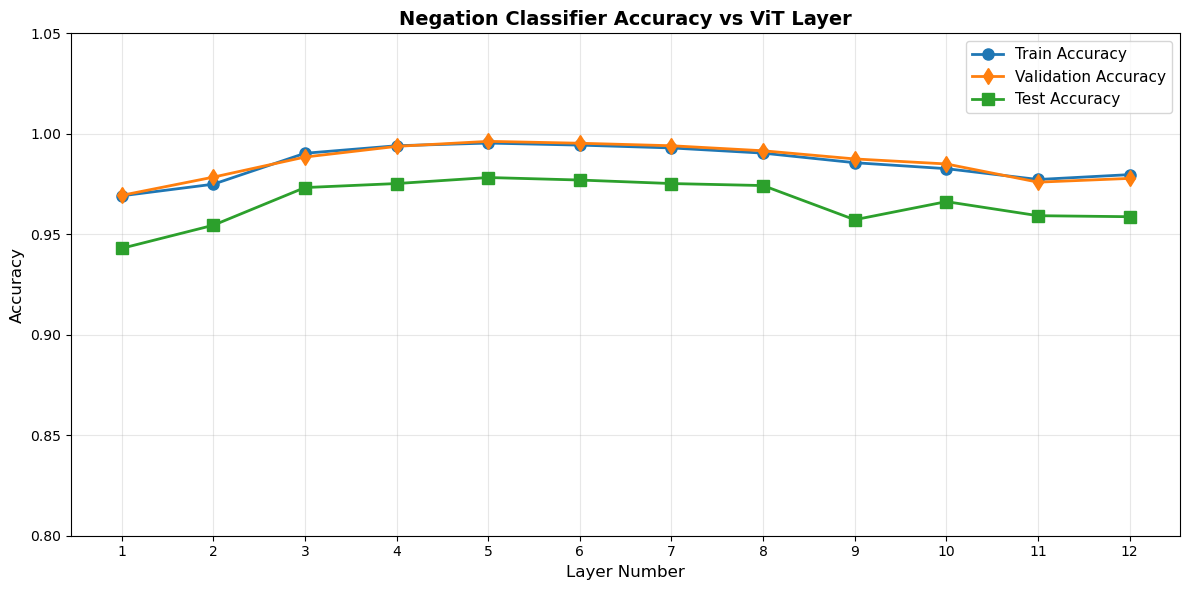


LAYER-BY-LAYER RESULTS:
----------------------------------------------------------------------
Layer    Train Acc       Validation Acc  Test Acc        Difference     
----------------------------------------------------------------------
1        0.9691          0.9694          0.9430          0.0261         
2        0.9749          0.9784          0.9545          0.0204         
3        0.9903          0.9884          0.9732          0.0171         
4        0.9941          0.9938          0.9752          0.0188         
5        0.9954          0.9962          0.9782          0.0171          ← Best Train ← Best Test ← Best Validation
6        0.9944          0.9953          0.9770          0.0174         
7        0.9930          0.9941          0.9752          0.0177         
8        0.9904          0.9916          0.9742          0.0161         
9        0.9856          0.9875          0.9573          0.0284         
10       0.9827          0.9850          0.9663          0.0

In [18]:
import matplotlib.pyplot as plt

# Configuration template - will iterate over layers
base_config_template = {"type": "vanilla", "arch": "ViT-B/32", "layer": None}

# Common experiment config
exp_config_template = {
    'dataset': "GEMINI_NEGATION_2",       
    'pos_variant': 'Baseline_CLIP',    # Must match the name used in extract_and_cache
    'neg_variant': 'Baseline_CLIP',    # Can be DEO_CLIP if you cached that
    'split_ratio': 0.8,                # Train/Test split for the classifier
    'val_split': 0.2,                  # Internal validation for the classifier
    'alpha': 0.5,                      # Steering strength (from the paper)
    'lr': 0.01,                        # Classifier learning rate
    'epochs': 120,                      # Classifier training epochs
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42
}

# Store results for each layer
layers = list(range(1, 13))  # Layers 1 to 12
train_accuracies = []
test_accuracies = []
val_accuracies = []
layer_results = {}

print("\n" + "="*70)
print("ITERATING OVER LAYERS 1-12 TO FIND OPTIMAL LAYER")
print("="*70)

# Iterate over each layer
for layer_idx, layer in enumerate(layers, 1):
    print(f"\n[{layer_idx}/12] Running experiment with Layer {layer}...")
    
    # Update config for this layer
    base_config = base_config_template.copy()
    base_config['layer'] = layer
    
    exp_config = exp_config_template.copy()
    exp_config['pos_config'] = base_config
    exp_config['neg_config'] = base_config
    
    # Run experiment
    try:
        results = run_paper_negation_experiment(exp_config)
        
        # Extract train and test accuracy from results
        # Assuming results dict contains 'train_accuracy' and 'test_accuracy'
        if isinstance(results, dict):
            train_acc = results.get('history', 0.0)
            if train_acc != 0.0:
                train_acc = train_acc['train_acc'][-1]  # Extract final training accuracy

            val_acc = results.get('history', 0.0)
            if val_acc != 0.0:
                val_acc = val_acc['val_acc'][-1]  # Extract final validation accuracy
            test_acc = results.get('test_acc', 0.0)

        else:
            # If results is a tuple/list, assume (train_acc, test_acc)
            train_acc = results[0] if len(results) > 0 else 0.0
            test_acc = results[1] if len(results) > 1 else 0.0
        
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        test_accuracies.append(test_acc)
        layer_results[layer] = {'train': train_acc, 'test': test_acc, 'val': val_acc}
        
        print(f"  ✓ Layer {layer}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")
    except Exception as e:
        print(f"  ✗ Error with Layer {layer}: {e}")
        train_accuracies.append(0.0)
        val_accuracies.append(0.0)
        test_accuracies.append(0.0)
        layer_results[layer] = {'train': 0.0, 'test': 0.0, 'val': 0.0}

# Plot results
print("\n" + "="*70)
print("PLOTTING RESULTS")
print("="*70)

plt.figure(figsize=(12, 6))
plt.plot(layers, train_accuracies, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(layers, val_accuracies, 'd-', label='Validation Accuracy', linewidth=2, markersize=8)
plt.plot(layers, test_accuracies, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Layer Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Negation Classifier Accuracy vs ViT Layer', fontsize=14, fontweight='bold')
plt.xticks(layers)
plt.ylim([0.8, 1.05])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary
print("\nLAYER-BY-LAYER RESULTS:")
print("-" * 70)
print(f"{'Layer':<8} {'Train Acc':<15} {'Validation Acc':<15} {'Test Acc':<15} {'Difference':<15}")
print("-" * 70)

best_layer_train = max(layer_results.items(), key=lambda x: x[1]['train'])
best_layer_test = max(layer_results.items(), key=lambda x: x[1]['test'])
best_layer_val = max(layer_results.items(), key=lambda x: x[1]['val'])

for layer in layers:
    train_acc = layer_results[layer]['train']
    val_acc = layer_results[layer]['val']
    test_acc = layer_results[layer]['test']
    diff = abs(train_acc - test_acc)
    marker = ""
    if layer == best_layer_train[0]:
        marker += " ← Best Train"
    if layer == best_layer_test[0]:
        marker += " ← Best Test"
    if layer == best_layer_val[0]:
        marker += " ← Best Validation"
    print(f"{layer:<8} {train_acc:<15.4f} {val_acc:<15.4f} {test_acc:<15.4f} {diff:<15.4f}{marker}")

print("-" * 70)
print(f"\n✓ Best Layer (Train):  Layer {best_layer_train[0]} with {best_layer_train[1]['train']:.4f}")
print(f"✓ Best Layer (Test):   Layer {best_layer_test[0]} with {best_layer_test[1]['test']:.4f}")
print(f"✓ Best Layer (Validation):   Layer {best_layer_val[0]} with {best_layer_val[1]['val']:.4f}")
print("="*70)


In [19]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}

# If you want to compare against your DEO features, use that config
# Otherwise, you can compare Baseline Pos vs Baseline Neg
exp_config = {
    'dataset': "GEMINI_NEGATION_2",       
    'pos_variant': 'Baseline_CLIP',    # Must match the name used in extract_and_cache
    'neg_variant': 'Baseline_CLIP',    # Can be DEO_CLIP if you cached that,,
    'pos_config': base_config,
    'neg_config': base_config,
    'split_ratio': 0.8,                # Train/Test split for the classifier
    'val_split': 0.2,                  # Internal validation for the classifier
    'alpha': 0.5,                      # Steering strength (from the paper)
    'lr': 0.01,                        # Classifier learning rate
    'epochs': 100,                      # Classifier training epochs
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42
}
run_paper_negation_experiment(exp_config)

--- Found cached features: ./embeddings_cache/Baseline_CLIP_c013ac4dc2148e5b54cd9bbd9fe56601.pt ---
--- Found cached features: ./embeddings_cache/Baseline_CLIP_c013ac4dc2148e5b54cd9bbd9fe56601.pt ---


/tmp/ipykernel_487588/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Epoch 001 | Train Acc: 0.9298 | Loss: 0.37564 | Val Acc: 0.9731 | Loss: 0.22176 | LR: 1.0e-02
Epoch 010 | Train Acc: 0.9913 | Loss: 0.04680 | Val Acc: 0.9928 | Loss: 0.04496 | LR: 1.0e-02
Epoch 020 | Train Acc: 0.9935 | Loss: 0.03499 | Val Acc: 0.9931 | Loss: 0.03457 | LR: 1.0e-02
Epoch 030 | Train Acc: 0.9943 | Loss: 0.03295 | Val Acc: 0.9938 | Loss: 0.03290 | LR: 1.0e-02
Epoch 040 | Train Acc: 0.9938 | Loss: 0.03252 | Val Acc: 0.9959 | Loss: 0.03313 | LR: 1.0e-02
Epoch 050 | Train Acc: 0.9938 | Loss: 0.03240 | Val Acc: 0.9944 | Loss: 0.03234 | LR: 1.0e-02
Epoch 060 | Train Acc: 0.9943 | Loss: 0.03223 | Val Acc: 0.9950 | Loss: 0.03243 | LR: 1.0e-02
Epoch 070 | Train Acc: 0.9943 | Loss: 0.03211 | Val Acc: 0.9950 | Loss: 0.03230 | LR: 1.0e-02
Epoch 080 | Train Acc: 0.9942 | Loss: 0.03207 | Val Acc: 0.9956 | Loss: 0.03274 | LR: 1.0e-02
Epoch 090 | Train Acc: 0.9941 | Loss: 0.03217 | Val Acc: 0.9947 | Loss: 0.03218 | LR: 1.0e-02
Epoch 100 | Train Acc: 0.9937 | Loss: 0.03227 | Val Acc: 0.9

{'W_dir': tensor([[-1.8450e-02,  1.1175e-01, -1.0059e-02, -5.2690e-02, -7.4618e-03,
           5.9395e-03,  6.2639e-03,  3.3100e-02,  7.1994e-02,  9.4307e-02,
           2.7474e-02, -2.7371e-02,  4.7687e-02, -3.6782e-02,  3.6968e-02,
           1.0008e-01, -2.6737e-03, -4.9637e-02,  2.4179e-03,  2.8120e-02,
           2.0146e-02,  1.7420e-02, -2.5310e-02, -5.5258e-02, -1.1065e-01,
           1.5671e-02, -4.5292e-02,  1.5420e-02,  3.1536e-02, -4.1861e-02,
          -3.9103e-02, -3.7044e-02,  2.9957e-02,  1.6014e-02, -7.0781e-02,
          -4.4692e-03,  3.8030e-02,  1.7746e-02,  3.4568e-02,  4.4422e-03,
          -6.2742e-02, -3.7053e-02, -1.9873e-02, -2.6391e-02, -3.7667e-02,
           1.1992e-03, -2.2075e-03,  4.4287e-02, -1.6105e-02, -2.5093e-02,
           7.1520e-02, -7.0374e-03, -8.5571e-03, -1.1600e-02, -1.4275e-02,
          -4.6402e-02, -4.1602e-02,  2.5100e-02, -6.9989e-02,  5.8700e-02,
          -1.4147e-02,  9.7741e-02,  3.4561e-02, -7.3171e-02,  6.0832e-02,
          -6.646

In [21]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}

# If you want to compare against your DEO features, use that config
# Otherwise, you can compare Baseline Pos vs Baseline Neg
exp_config = {
    'dataset': "NegationCLIP",
    'pos_variant': 'Baseline_CLIP',    # Must match the name used in extract_and_cache
    'neg_variant': 'Baseline_CLIP',    # Can be DEO_CLIP if you cached that,,
    'pos_config': base_config,
    'neg_config': base_config,
    'split_ratio': 0.8,                # Train/Test split for the classifier
    'val_split': 0.2,                  # Internal validation for the classifier
    'alpha': 0.5,                      # Steering strength (from the paper)
    'lr': 0.01,                        # Classifier learning rate
    'epochs': 500,                      # Classifier training epochs
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42
}
run_paper_negation_experiment(exp_config)


--- Found cached features: ./embeddings_cache/Baseline_CLIP_43e228572a9931f231278079a4d4f81b.pt ---
--- Found cached features: ./embeddings_cache/Baseline_CLIP_43e228572a9931f231278079a4d4f81b.pt ---


/tmp/ipykernel_640588/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Epoch 001 | Train Acc: 0.8357 | Loss: 0.49972 | Val Acc: 0.8857 | Loss: 0.38424 | LR: 1.0e-02
Epoch 010 | Train Acc: 0.9363 | Loss: 0.18578 | Val Acc: 0.9366 | Loss: 0.18354 | LR: 1.0e-02
Epoch 020 | Train Acc: 0.9435 | Loss: 0.16296 | Val Acc: 0.9393 | Loss: 0.16496 | LR: 1.0e-02
Epoch 030 | Train Acc: 0.9454 | Loss: 0.15550 | Val Acc: 0.9411 | Loss: 0.15972 | LR: 1.0e-02
Epoch 040 | Train Acc: 0.9467 | Loss: 0.15187 | Val Acc: 0.9424 | Loss: 0.15660 | LR: 1.0e-02
Epoch 050 | Train Acc: 0.9467 | Loss: 0.14977 | Val Acc: 0.9424 | Loss: 0.15513 | LR: 1.0e-02
Epoch 060 | Train Acc: 0.9492 | Loss: 0.14890 | Val Acc: 0.9451 | Loss: 0.15513 | LR: 1.0e-02
Epoch 070 | Train Acc: 0.9483 | Loss: 0.14820 | Val Acc: 0.9451 | Loss: 0.15458 | LR: 1.0e-02
Epoch 080 | Train Acc: 0.9497 | Loss: 0.14783 | Val Acc: 0.9446 | Loss: 0.15443 | LR: 1.0e-02
Epoch 090 | Train Acc: 0.9483 | Loss: 0.14759 | Val Acc: 0.9442 | Loss: 0.15363 | LR: 1.0e-02
Epoch 100 | Train Acc: 0.9479 | Loss: 0.14704 | Val Acc: 0.9

KeyboardInterrupt: 

In [ ]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}

# If you want to compare against your DEO features, use that config
# Otherwise, you can compare Baseline Pos vs Baseline Neg
exp_config = {
    'dataset': "NegationCLIP",
    'pos_variant': 'Baseline_CLIP_14000',    # Must match the name used in extract_and_cache
    'neg_variant': 'Baseline_CLIP_14000',    # Can be DEO_CLIP if you cached that,,
    'pos_config': base_config,
    'neg_config': base_config,
    'split_ratio': 0.8,                # Train/Test split for the classifier
    'val_split': 0.2,                  # Internal validation for the classifier
    'alpha': 0.5,                      # Steering strength (from the paper)
    'lr': 0.001,                        # Classifier learning rate
    'epochs': 250,                      # Classifier training epochs
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42
}
run_paper_negation_experiment(exp_config)


--- Found cached features: ./embeddings_cache/Baseline_CLIP_14000_120b7477eabe192a19c0baf063464394.pt ---
--- Found cached features: ./embeddings_cache/Baseline_CLIP_14000_120b7477eabe192a19c0baf063464394.pt ---


/tmp/ipykernel_273155/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Epoch 001 | Train Acc: 0.7823 | Loss: 0.63458 | Val Acc: 0.8158 | Loss: 0.58295 | LR: 1.0e-03
Epoch 010 | Train Acc: 0.9125 | Loss: 0.29828 | Val Acc: 0.9147 | Loss: 0.29040 | LR: 1.0e-03
Epoch 020 | Train Acc: 0.9269 | Loss: 0.22635 | Val Acc: 0.9292 | Loss: 0.22378 | LR: 1.0e-03
Epoch 030 | Train Acc: 0.9333 | Loss: 0.20018 | Val Acc: 0.9346 | Loss: 0.19986 | LR: 1.0e-03
Epoch 040 | Train Acc: 0.9363 | Loss: 0.18701 | Val Acc: 0.9371 | Loss: 0.18748 | LR: 1.0e-03
Epoch 050 | Train Acc: 0.9382 | Loss: 0.17907 | Val Acc: 0.9395 | Loss: 0.18025 | LR: 1.0e-03
Epoch 060 | Train Acc: 0.9403 | Loss: 0.17374 | Val Acc: 0.9404 | Loss: 0.17570 | LR: 1.0e-03
Epoch 070 | Train Acc: 0.9414 | Loss: 0.16986 | Val Acc: 0.9413 | Loss: 0.17216 | LR: 1.0e-03
Epoch 080 | Train Acc: 0.9421 | Loss: 0.16693 | Val Acc: 0.9417 | Loss: 0.16905 | LR: 1.0e-03
Epoch 090 | Train Acc: 0.9431 | Loss: 0.16471 | Val Acc: 0.9422 | Loss: 0.16734 | LR: 1.0e-03
Epoch 100 | Train Acc: 0.9437 | Loss: 0.16288 | Val Acc: 0.9

{'W_dir': tensor([[-4.9875e-02,  1.4757e-01,  9.8352e-02, -3.2421e-02, -6.8117e-03,
           4.2873e-02,  5.3455e-02,  2.4586e-02,  8.3640e-03,  8.2568e-02,
           3.3753e-02, -5.3776e-02, -2.7860e-02,  2.2298e-02,  4.3314e-02,
          -1.0039e-02, -2.2201e-02, -5.1941e-02,  1.6941e-02,  6.8541e-02,
           2.8037e-02,  1.7021e-02, -2.8479e-02, -5.2851e-02, -8.4929e-02,
           4.4060e-02,  1.7847e-02, -1.4459e-02,  3.2910e-02, -3.2115e-02,
          -1.3510e-02,  2.0968e-02,  3.6567e-02,  1.8782e-02, -6.2217e-02,
           1.2596e-02, -1.2342e-02,  1.4415e-02,  4.2199e-02, -8.8644e-03,
           1.2874e-02, -4.8770e-02, -5.3390e-02, -9.7077e-02, -7.2392e-02,
          -5.3760e-02, -2.2467e-02,  4.4372e-02,  4.4909e-02, -9.8772e-02,
           1.1487e-02,  3.9586e-02, -3.1782e-02,  8.8774e-02,  4.8807e-02,
          -7.6953e-02,  2.9152e-02,  6.0890e-02, -8.1577e-02,  5.8515e-02,
           3.3307e-02, -1.8102e-02,  9.0390e-02, -1.9043e-02,  6.5652e-02,
          -3.906

In [130]:
base_config = {"type": "vanilla", "arch": "ViT-B/32", "layer": 4}

# If you want to compare against your DEO features, use that config
# Otherwise, you can compare Baseline Pos vs Baseline Neg
exp_config = {
    'dataset': "GEMINI_NEGATION",          # Must match the name used in extract_and_cache
    'pos_variant': 'Baseline_CLIP_Gemini',    # Must match the name used in extract_and_cache
    'neg_variant': 'Baseline_CLIP_Gemini',    # Can be DEO_CLIP if you cached that,,
    'pos_config': base_config,
    'neg_config': base_config,
    'split_ratio': 0.8,                # Train/Test split for the classifier
    'val_split': 0.2,                  # Internal validation for the classifier
    'alpha': 0.5,                      # Steering strength (from the paper)
    'lr': 0.01,                        # Classifier learning rate
    'epochs': 90,                      # Classifier training epochs
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42
}
run_paper_negation_experiment(exp_config)


--- Found cached features: ./embeddings_cache/Baseline_CLIP_Gemini_69e9c1072331f9acad27b90f6f251cc6.pt ---
--- Found cached features: ./embeddings_cache/Baseline_CLIP_Gemini_69e9c1072331f9acad27b90f6f251cc6.pt ---


/tmp/ipykernel_273155/3879348306.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Epoch 001 | Train Acc: 0.9563 | Loss: 0.37781 | Val Acc: 0.9981 | Loss: 0.20322 | LR: 1.0e-02
Epoch 010 | Train Acc: 1.0000 | Loss: 0.01768 | Val Acc: 1.0000 | Loss: 0.01701 | LR: 1.0e-02
Epoch 020 | Train Acc: 1.0000 | Loss: 0.01239 | Val Acc: 1.0000 | Loss: 0.01232 | LR: 1.0e-02
Epoch 030 | Train Acc: 1.0000 | Loss: 0.01141 | Val Acc: 1.0000 | Loss: 0.01135 | LR: 1.0e-02
Epoch 040 | Train Acc: 1.0000 | Loss: 0.01105 | Val Acc: 1.0000 | Loss: 0.01095 | LR: 1.0e-02
Epoch 050 | Train Acc: 1.0000 | Loss: 0.01081 | Val Acc: 1.0000 | Loss: 0.01088 | LR: 1.0e-02
Epoch 060 | Train Acc: 1.0000 | Loss: 0.01075 | Val Acc: 1.0000 | Loss: 0.01064 | LR: 1.0e-02
Epoch 070 | Train Acc: 1.0000 | Loss: 0.01064 | Val Acc: 1.0000 | Loss: 0.01062 | LR: 1.0e-02
Epoch 080 | Train Acc: 1.0000 | Loss: 0.01061 | Val Acc: 1.0000 | Loss: 0.01056 | LR: 1.0e-02
Epoch 090 | Train Acc: 1.0000 | Loss: 0.01058 | Val Acc: 1.0000 | Loss: 0.01047 | LR: 1.0e-02

NEGATION EXPERIMENT: Baseline_CLIP_Gemini
Classifier Traini

{'W_dir': tensor([[ 0.0478,  0.0692,  0.0325, -0.0421, -0.0004,  0.0423,  0.0504,  0.0385,
           0.0332,  0.0775,  0.0695, -0.0452,  0.0738, -0.0570,  0.0496,  0.0535,
          -0.0618, -0.0624, -0.0474, -0.0453,  0.0304,  0.0224, -0.0596, -0.0292,
          -0.0629,  0.0322,  0.0088,  0.0185, -0.0432,  0.0253, -0.0374,  0.0503,
           0.0379, -0.0062, -0.0588, -0.0580, -0.0170,  0.0088,  0.0649, -0.0005,
          -0.0491,  0.0074, -0.0531, -0.0306, -0.0190, -0.0577,  0.0354,  0.0369,
          -0.0367, -0.0663,  0.0524, -0.0478, -0.0102,  0.0347,  0.0404, -0.0162,
           0.0325, -0.0302, -0.0627,  0.0592,  0.0033,  0.0399,  0.0476, -0.0706,
           0.0365, -0.0592,  0.0463, -0.0263,  0.0441,  0.0676,  0.0764, -0.0674,
           0.0608,  0.0530,  0.0479,  0.0579, -0.0170,  0.0689, -0.0168,  0.0578,
          -0.0539,  0.0125, -0.0143, -0.0483,  0.0354,  0.0484,  0.0142,  0.0586,
          -0.0189,  0.0257, -0.0586, -0.0375,  0.0454, -0.0637,  0.0057,  0.0196,
       